In [2]:
import torch 
import torch.nn as nn 
import numpy as np 
import random 
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader


epoch=01 | train_loss=0.5704 | test_loss=0.4558 | test_acc=0.8385
epoch=02 | train_loss=0.4126 | test_loss=0.4380 | test_acc=0.8400
epoch=03 | train_loss=0.3681 | test_loss=0.3999 | test_acc=0.8527
epoch=04 | train_loss=0.3396 | test_loss=0.3633 | test_acc=0.8697
epoch=05 | train_loss=0.3183 | test_loss=0.3519 | test_acc=0.8731
epoch=06 | train_loss=0.3028 | test_loss=0.3580 | test_acc=0.8723
epoch=07 | train_loss=0.2879 | test_loss=0.3396 | test_acc=0.8754
epoch=08 | train_loss=0.2756 | test_loss=0.3313 | test_acc=0.8803
epoch=09 | train_loss=0.2647 | test_loss=0.3277 | test_acc=0.8825
epoch=10 | train_loss=0.2533 | test_loss=0.3253 | test_acc=0.8830
epoch=11 | train_loss=0.2445 | test_loss=0.3142 | test_acc=0.8875
epoch=12 | train_loss=0.2387 | test_loss=0.3121 | test_acc=0.8891
epoch=13 | train_loss=0.2295 | test_loss=0.3089 | test_acc=0.8881
epoch=14 | train_loss=0.2244 | test_loss=0.3200 | test_acc=0.8890
epoch=15 | train_loss=0.2157 | test_loss=0.3217 | test_acc=0.8887
epoch=16 |

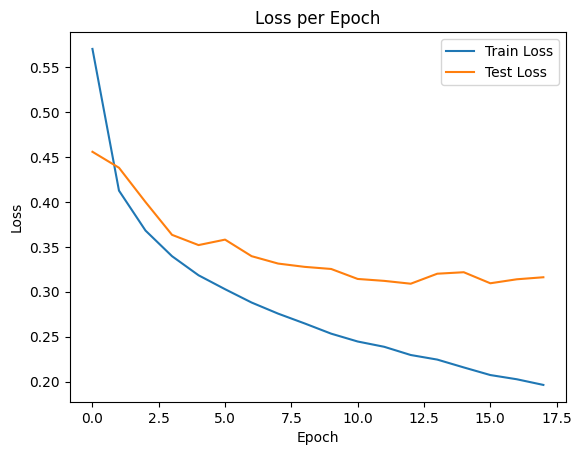

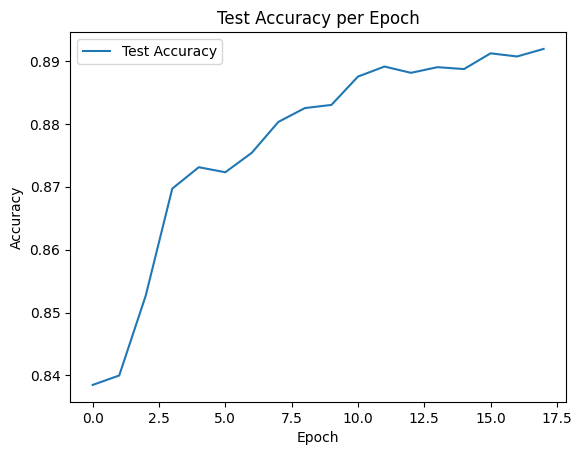

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

train_ds = FashionMNIST (
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_ds = FashionMNIST (
    root="./data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_loader = DataLoader(train_ds, batch_size=156, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1064, shuffle=False)

class FashionMNIST_MLP(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.fc1 = nn.Linear(28*28, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 10)

    def forward(self,x):
        x = x.view(x.size(0), -1)   
        x = self.fc1(x)            
        x = self.act(x)
        x = self.fc2(x)            
        return x 
    
model = FashionMNIST_MLP(hidden=256)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_test_loss = float("inf")
patience = 5
epochs_no_improve = 0

EPOCH = 30

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCH):
    model.train()
    train_loss_sum = 0.0

    for x_batch, y_batch in train_loader:
        logits = model(x_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(train_loader)

    model.eval()
    test_loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            test_loss_sum += loss.item()

            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    test_loss = test_loss_sum / len(test_loader)
    test_acc = correct / total

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(
        f"epoch={epoch+1:02d} | train_loss={train_loss:.4f} | "
        f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f}"
    )

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break 

print({
  "optimizer": "Adam",
  "lr": 1e-3,
  "activation": "ReLU",
  "epochs": EPOCH,
  "hidden": 256,
  "final_test_acc": test_acc,
})

import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("../assets/loss_curve2.png")
plt.show()


plt.figure()
plt.plot(test_accuracies, label="Test Accuracy")
plt.legend()
plt.title("Test Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("../assets/accuracy_curve2.png")
plt.show()
 
